# Depth Anything V2 Model - KITTI Evaluation

Load and test `depth-anything/Depth-Anything-V2-Metric-Outdoor-Small-hf` on some KITTI depth-prediction validation images and compare with LiDAR.

Note: Best to run this notebok with a GPU.

## Install Dependencies

In [ ]:
!pip install -q --upgrade transformers accelerate

   ======================================== 10.8/10.8 MB 85.1 MB/s eta 0:00:00


In [ ]:
import os, zipfile, pathlib
import random

## Download KITTI Depth Validation Data

Zip with 1000 images and LiDAR depth from KITTI.  
The zip size is about 1.9 GB and can take a few minutes to download.

In [ ]:
data_dir = pathlib.Path('kitti_depth')
zip_path = data_dir / 'val_selection.zip'

data_dir.mkdir(exist_ok=True)

if not zip_path.exists():
  print('Downloading KITTI validation data')
  !wget -q --show-progress -O {zip_path} 'https://s3.eu-central-1.amazonaws.com/avg-kitti/data_depth_selection.zip'
  print('Finished download')
else:
  print('Already downloaded')

kitti_depth/val_sel 100%[===================>]   1.87G  17.2MB/s    in 1m 43s  
Finished download


In [ ]:
with zipfile.ZipFile(zip_path) as zf:
  zf.extractall(data_dir)

print('Extracted zip file')

Extracted zip file


In [ ]:
val_dir = data_dir / 'depth_selection/val_selection_cropped'

img_files = sorted((val_dir / 'image').glob('*.png'))
gt_files = sorted((val_dir / 'groundtruth_depth').glob('*.png'))

random.shuffle(img_files)
random.shuffle(gt_files)

print(f'{len(img_files)} images and {len(gt_files)} ground truth files')

1000 images and 1000 ground truth files


## Load Model

In [ ]:
import torch
from transformers import AutoImageProcessor, AutoModelForDepthEstimation

model_id = 'depth-anything/Depth-Anything-V2-Metric-Outdoor-Small-hf'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


In [ ]:
processor = AutoImageProcessor.from_pretrained(model_id)
model = AutoModelForDepthEstimation.from_pretrained(model_id).to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/437 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

DepthAnythingForDepthEstimation(
  (backbone): Dinov2Backbone(
    (embeddings): Dinov2Embeddings(
      (patch_embeddings): Dinov2PatchEmbeddings(
        (projection): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): Dinov2Encoder(
      (layer): ModuleList(
        (0-11): 12 x Dinov2Layer(
          (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
          (attention): Dinov2Attention(
            (attention): Dinov2SelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
            )
            (output): Dinov2SelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (layer_scale1): Di

## Run Inference on Sample Data

In [ ]:
import numpy as np
from PIL import Image
from tqdm import tqdm

# Configuration Variables
n_samples = 1000
max_depth = 80.0 # meteres (outdoor model cap)
min_depth = 1e-3 # meters (ignore near zero)

def load_gt_depth(path):
  depth = np.array(Image.open(path), dtype=np.float32)
  return depth / 256.0 # KITTI encoding is depth_m * 256

@torch.inference_mode()
def predict_depth(pil_image):
  inputs = processor(images=pil_image, return_tensors='pt').to(device)
  outputs = model(**inputs)
  pred = outputs.predicted_depth.squeeze().cpu().float().numpy()
  return pred

results = [] # list of (pred, gt, rgb_image) dict

for idx in tqdm(range(n_samples), desc="Running inference"):
  rgb = Image.open(img_files[idx]).convert('RGB')
  gt = load_gt_depth(gt_files[idx])

  pred = predict_depth(rgb)

  gt_h, gt_w = gt.shape
  pred = np.array(Image.fromarray(pred).resize((gt_w, gt_h), Image.BILINEAR))

  results.append(dict(pred=pred, gt=gt, rgb=rgb, fname=img_files[idx].name))

print('Finished inference')

Running inference: 100%|##########| 1000/1000 [05:01<00:00,  3.31it/s]

Finished inference


## Evaluate Model

In [ ]:
def compute_metrics(pred, gt, min_depth=min_depth, max_depth=max_depth):
  mask = (gt > min_depth) & (gt < max_depth)
  if mask.sum() == 0:
    return {k: float('nan') for k in ['abs_rel', 'rmse', 'n_valid']}

  p = pred[mask].clip(min_depth, max_depth)
  g = gt[mask]

  rmse = np.sqrt(((g - p) ** 2).mean())
  abs_rel = (np.abs(g - p) / g).mean()

  return dict(abs_rel=abs_rel, rmse=rmse, n_valid=int(mask.sum()))

all_metrics = [compute_metrics(r['pred'], r['gt']) for r in results]

keys = ['abs_rel', 'rmse']
mean_m = {k: float(np.nanmean([m[k] for m in all_metrics])) for k in keys}

print('Mean Metrics for Model Evaluation on Validation Data')
print(f'AbsRel: {mean_m['abs_rel']:.4f}')
print(f'RMSE: {mean_m['rmse']:.4f}')

Mean Metrics for Model Evaluation on Validation Data
AbsRel: 0.3025
RMSE: 9.6117


## Visualize Predictions and Ground Truth

Show RGB image, predicted depth, ground truth depth, and error map

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

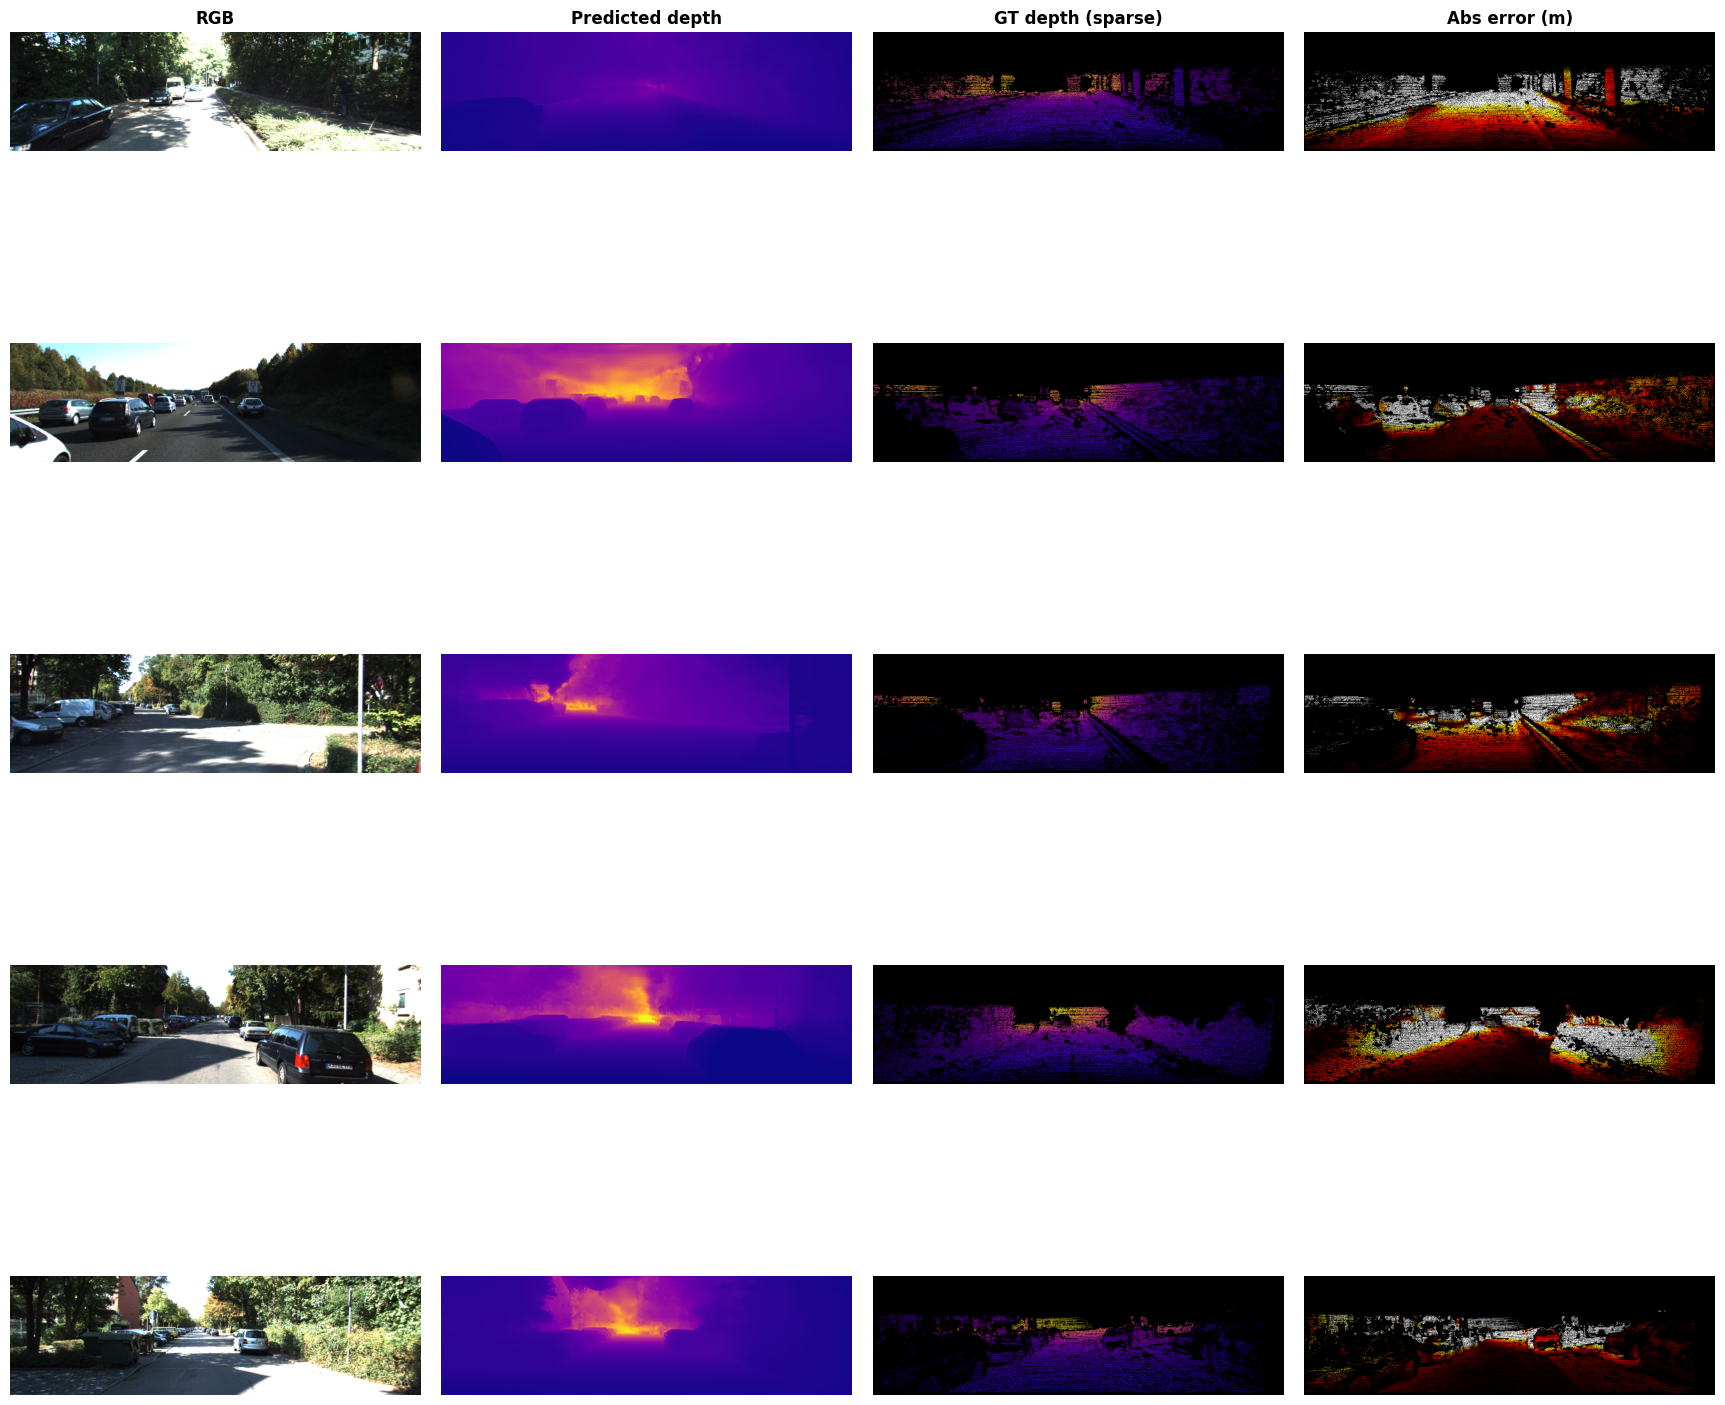

In [ ]:
def colorize(depth_map, vmin=None, vmax=None, cmap='plasma'):
  d = depth_map.copy().astype(np.float32)
  valid = d > 0
  if vmin is None: vmin = d[valid].min() if valid.any() else 0
  if vmax is None: vmax = d[valid].max() if valid.any() else 1
  d = np.clip(d, vmin, vmax)
  d_norm = (d - vmin) / (vmax - vmin + 1e-8)
  cm = plt.get_cmap(cmap)
  rgba = cm(d_norm)
  rgb = (rgba[:, :, :3] * 255).astype(np.uint8)

  rgb[~valid] = 0
  return rgb

n_vis = min(5, n_samples)
col_titles = ['RGB', 'Predicted depth', 'GT depth (sparse)', 'Abs error (m)']

fig, axes = plt.subplots(n_vis, 4, figsize=(22, 4 * n_vis),
                         gridspec_kw={'hspace': 0.05, 'wspace': 0.05})

axes = np.atleast_2d(axes)

for col, title in enumerate(col_titles):
  axes[0, col].set_title(title, fontsize=12, fontweight='bold')

for row, r in enumerate(results[:n_vis]):
  pred, gt = r['pred'], r['gt']
  mask = gt > min_depth
  vmin, vmax = (gt[mask].min(), gt[mask].max()) if mask.any() else (0, max_depth)

  err = np.zeros_like(pred)
  err[mask] = np.abs(pred[mask] - gt[mask])

  images = [r['rgb'], colorize(pred, vmin, vmax),
            colorize(gt, vmin, vmax), colorize(err, vmin=0, vmax=5, cmap='hot')]

  for ax, img in zip(axes[row], images):
      ax.imshow(img)
      ax.axis('off')

  axes[row, 0].set_ylabel(r['fname'][:30], fontsize=8)

plt.show()

GT   - min: 4.00  max: 81.12  mean: 14.22
Pred - min: 4.78  max: 77.67  mean: 21.26
Scale factor: 1.102


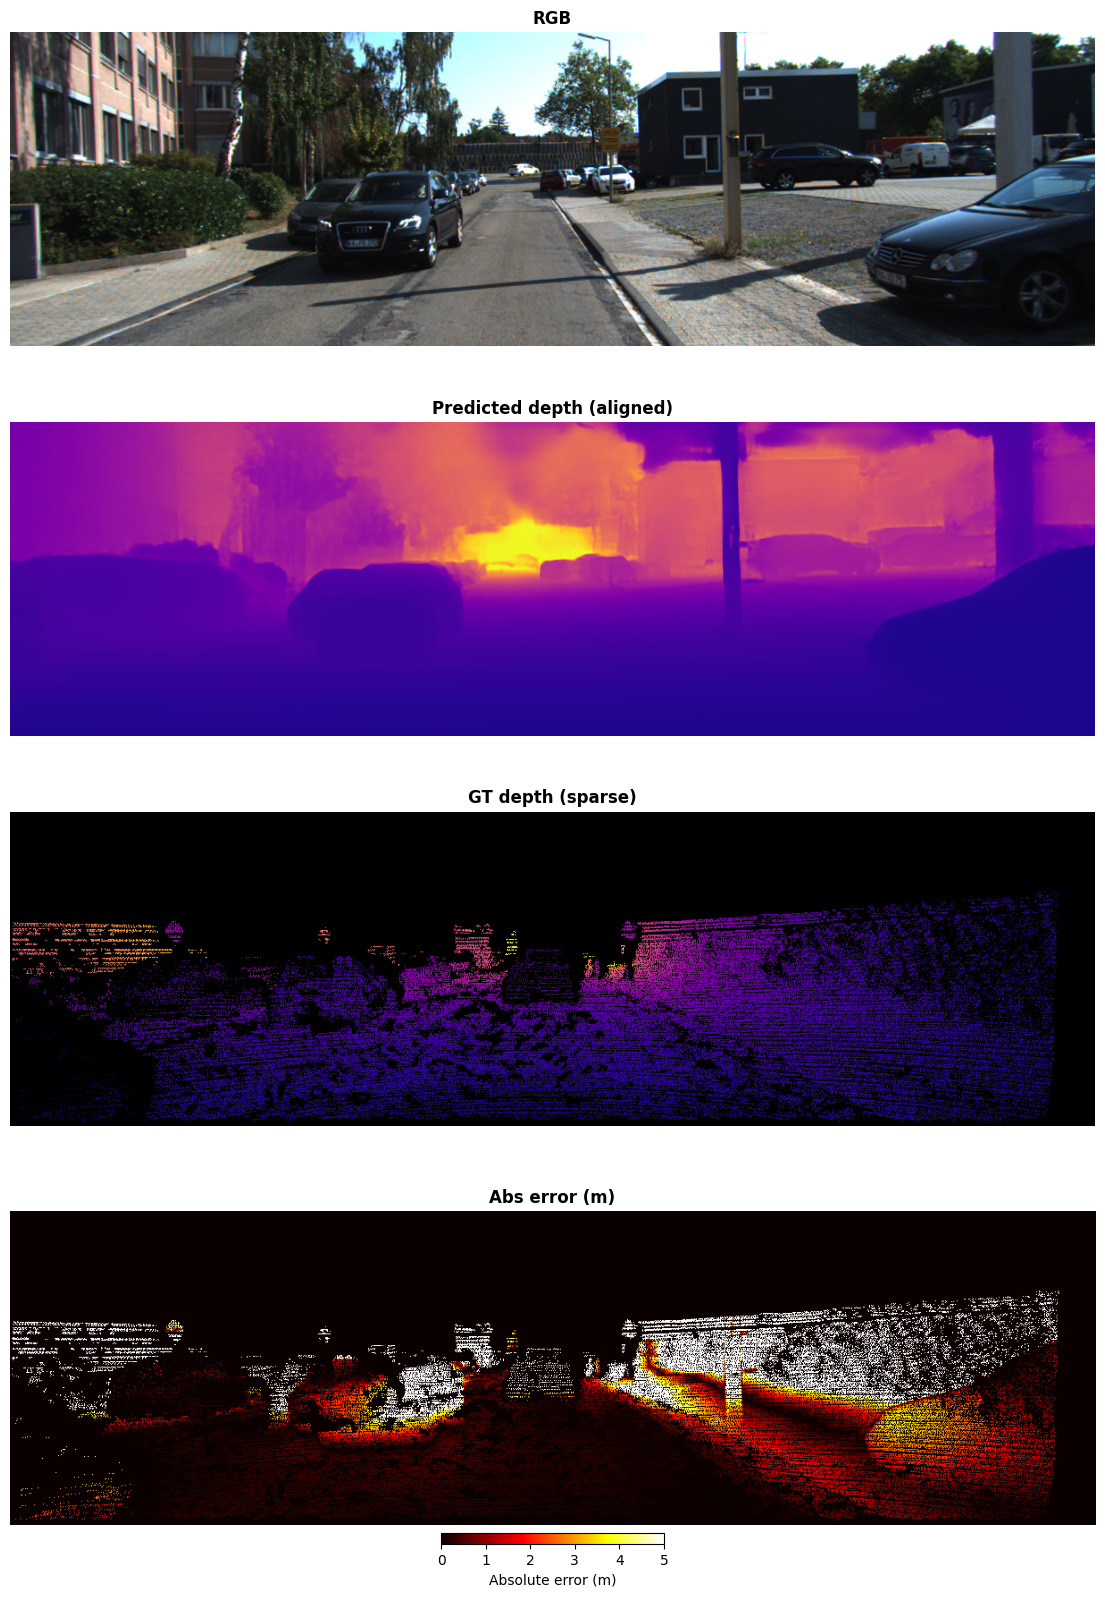

In [ ]:
r = results[100]

pred, gt = r['pred'], r['gt']
mask = gt > min_depth
vmin, vmax = (gt[mask].min(), gt[mask].max()) if mask.any() else (0, max_depth)

print(f"GT   - min: {gt[mask].min():.2f}  max: {gt[mask].max():.2f}  mean: {gt[mask].mean():.2f}")
print(f"Pred - min: {pred.min():.2f}  max: {pred.max():.2f}  mean: {pred.mean():.2f}")

# Median scale alignment
scale = np.median(gt[mask]) / np.median(pred[mask])
print(f"Scale factor: {scale:.3f}")
pred_aligned = pred * scale

# Error on aligned prediction
err = np.zeros_like(pred_aligned)
err[mask] = np.abs(pred_aligned[mask] - gt[mask])

col_titles = ['RGB', 'Predicted depth (aligned)', 'GT depth (sparse)', 'Abs error (m)']
images = [
  r['rgb'],
  colorize(pred_aligned, vmin, vmax),
  colorize(gt, vmin, vmax),
  colorize(err, vmin=0, vmax=5, cmap='hot')
]

fig, axes = plt.subplots(4, 1, figsize=(14, 20),
                         gridspec_kw={'hspace': 0.05})

for ax, img, title in zip(axes, images, col_titles):
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold')

err_im = axes[3].imshow(err, cmap='hot', vmin=0, vmax=5)
axes[3].axis('off')
axes[3].set_title(col_titles[3], fontsize=12, fontweight='bold')
fig.colorbar(err_im, ax=axes[3], orientation='horizontal',
             fraction=0.03, pad=0.02, label='Absolute error (m)')

plt.show()

## Evaluation Metrics

In [ ]:
!pip install -q kaggle

In [ ]:
import os
import numpy as np
import torch
from PIL import Image
from tqdm import tqdm

In [ ]:
import kagglehub

# Download Eigensplit KITTI data from Kaggle
path = kagglehub.dataset_download("awsaf49/kitti-eigen-split-dataset")

print("Path to dataset files:", path)

100%|##########| 21.7G/21.7G [21:33<00:00, 18.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/awsaf49/kitti-eigen-split-dataset/versions/1


### Utility Functions for Evaluation

In [ ]:
def compute_metrics(gt, pred, min_depth=1e-3, max_depth=80.0):
  """
  gt, pred: full numpy arrays (H, W)
  Applies standard Eigen eval mask before computing.
  """

  mask = (gt > min_depth) & (gt <= max_depth) & (pred > min_depth)

  gt   = gt[mask]
  pred = pred[mask]

  thresh = np.maximum(gt / pred, pred / gt)

  return {
    "abs_rel": float((np.abs(gt - pred) / gt).mean()),
    "sq_rel": float((((gt - pred) ** 2) / gt).mean()),
    "rmse": float(np.sqrt(((gt - pred) ** 2).mean())),
    "rmse_log": float(np.sqrt(((np.log(gt) - np.log(pred)) ** 2).mean())),
    "d1": float((thresh < 1.25).mean()),
    "d2": float((thresh < 1.25 ** 2).mean()),
    "d3": float((thresh < 1.25 ** 3).mean()),
  }

In [ ]:
def get_test_pairs(kitti_root):
  """
  Walks test/ and returns list of (rgb_path, depth_path) pairs.
  proj_depth/ contains 16-bit PNG files encoded as depth_mm / 256.0
  """
  test_root = os.path.join(kitti_root, "test")
  pairs = []

  for date in sorted(os.listdir(test_root)):
    date_path = os.path.join(test_root, date)
    if not os.path.isdir(date_path):
      continue
    for drive in sorted(os.listdir(date_path)):
      drive_path = os.path.join(date_path, drive)
      rgb_dir = os.path.join(drive_path, "image_02", "data")
      depth_dir = os.path.join(drive_path, "proj_depth", "groundtruth", "image_02")

      if not os.path.isdir(depth_dir):
        depth_dir = os.path.join(drive_path, "proj_depth")

      if not (os.path.isdir(rgb_dir) and os.path.isdir(depth_dir)):
        print(f"  [WARN] Missing dirs in {drive}, skipping")
        continue

      rgb_files = sorted([f for f in os.listdir(rgb_dir)   if f.endswith(".png")])
      depth_files = sorted([f for f in os.listdir(depth_dir) if f.endswith(".png")])

      depth_names = set(depth_files)
      for rf in rgb_files:
        if rf in depth_names:
          pairs.append((
            os.path.join(rgb_dir,   rf),
            os.path.join(depth_dir, rf),
          ))

  print(f"Total paired samples found: {len(pairs)}")
  return pairs

KITTI_ROOT = path
test_pairs = get_test_pairs(KITTI_ROOT)

Total paired samples found: 652


In [ ]:
def load_gt_depth(depth_path):
  """
  KITTI GT depth PNGs are 16-bit, encoded as: depth_meters = pixel_value / 256.0
  Zero pixels = invalid (no LiDAR return).
  """
  depth_png = np.array(Image.open(depth_path), dtype=np.float32)
  depth = depth_png / 256.0
  return depth

def run_inference(rgb_path, gt_h, gt_w):
  image = Image.open(rgb_path).convert("RGB")
  inputs = processor(images=image, return_tensors="pt").to(device)

  with torch.no_grad():
    outputs = model(**inputs)
    pred = outputs.predicted_depth

  pred = torch.nn.functional.interpolate(
    pred.unsqueeze(1),
    size=(gt_h, gt_w),
    mode="bilinear",
    align_corners=False,
  ).squeeze().cpu().numpy()

  return pred

all_metrics = {k: [] for k in ["abs_rel", "sq_rel", "rmse", "rmse_log", "d1", "d2", "d3"]}
errors = []

for rgb_path, depth_path in tqdm(test_pairs, desc="Evaluating"):
  try:
    gt = load_gt_depth(depth_path)
    pred = run_inference(rgb_path, gt.shape[0], gt.shape[1])

    m = compute_metrics(gt, pred)
    for k, v in m.items():
      all_metrics[k].append(v)

  except Exception as e:
    errors.append((rgb_path, str(e)))

print(f"\nDone. Evaluated {len(all_metrics['abs_rel'])} images. Errors: {len(errors)}")

Evaluating: 100%|##########| 652/652 [01:25<00:00,  7.65it/s]


Done. Evaluated 652 images. Errors: 0


### Evaluation Results for the Model We Use

In [ ]:
print("\n" + "="*55)
print(f"  Depth Anything V2 Metric Outdoor Small - KITTI Eigen")
print("="*55)
print(f"  {'Metric':<12}  {'Value':>10}")
print("-"*55)

results = {k: np.mean(v) for k, v in all_metrics.items()}

# Lower is better
for k in ["abs_rel", "sq_rel", "rmse", "rmse_log"]:
  print(f"  {k:<12}  {results[k]:>10.4f}   (low=better)")

# Higher is better
for k in ["d1", "d2", "d3"]:
  label = {"d1": "delta<1.25", "d2": "delta<1.25^2", "d3": "delta<1.25^3"}[k]
  print(f"  {label:<12}  {results[k]:>10.4f}   (high=better)")

print("="*55)

if errors:
  print(f"\n[WARN] {len(errors)} files failed:")
  for path, err in errors[:5]:
    print(f"  {os.path.basename(path)}: {err}")


  Depth Anything V2 Metric Outdoor Small - KITTI Eigen
  Metric             Value
-------------------------------------------------------
  abs_rel           0.1367   (low=better)
  sq_rel            0.8600   (low=better)
  rmse              4.6578   (low=better)
  rmse_log          0.1955   (low=better)
  delta<1.25            0.8108   (high=better)
  delta<1.25^2           0.9439   (high=better)
  delta<1.25^3           0.9802   (high=better)


### Compare Evaluation Metrics

The results for these two models are pulled directly from the paper "Depth Anything V2" by Yang et al.  


AbsRel measures the average absolute relative error between the predicted depth and the ground truth depth. Lower is better since it means the error is smaller.

delta<1.25 measures the percent of pixels who have a depth predicted within a factor of 1.25 from the ground truth depth. Higher is better since it means more pixels are within the threshold.

Depth Anything V2 Base:  
- Parameters = 97 M
- AbsRel = 0.078
- delta<1.25 = 0.939

Depth Anything V2 Large:
- Parameters = 335 M
- AbsRel = 0.074
- delta<1.25 = 0.946

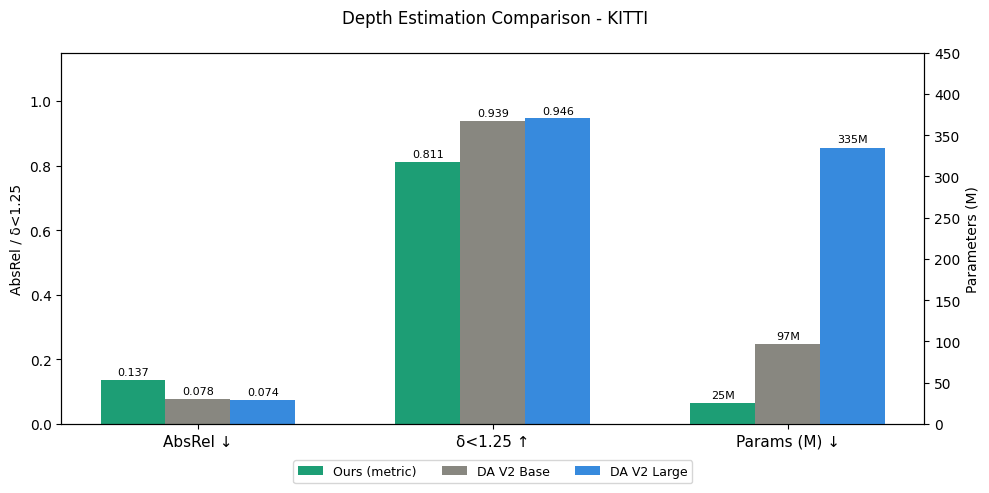

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Ours (metric)', 'DA V2 Base', 'DA V2 Large']
colors = ['#1D9E75', '#888780', '#378ADD']
absrel = [0.137, 0.078, 0.074]
delta = [0.811, 0.939, 0.946]
params = [25,    97,    335]
metrics = ['AbsRel (low=better)', 'delta<1.25 (high=better)', 'Params (M) (low=better)']
data = [absrel, delta, params]

x = np.arange(len(metrics))
width = 0.22
offsets = [-width, 0, width]

fig, ax_left = plt.subplots(figsize=(10, 5))
ax_right = ax_left.twinx()
fig.suptitle('Depth Estimation Comparison - KITTI', fontsize=12)

for i, (model, color, offset) in enumerate(zip(models, colors, offsets)):
  vals = [data[m][i] for m in range(len(metrics))]
  ax_left.bar(x[:2] + offset, vals[:2], width, color=color, label=model)
  for j, v in enumerate(vals[:2]):
    ax_left.text(x[j] + offset, v + 0.008, f'{v:.3f}',
                  ha='center', va='bottom', fontsize=8)
  ax_right.bar(x[2] + offset, vals[2], width, color=color)
  ax_right.text(x[2] + offset, vals[2] + 4, f'{vals[2]}M',
                ha='center', va='bottom', fontsize=8)

ax_left.set_ylabel('AbsRel / delta<1.25', fontsize=10)
ax_left.set_ylim(0, 1.15)
ax_right.set_ylabel('Parameters (M)', fontsize=10)
ax_right.set_ylim(0, 450)
ax_left.set_xticks(x)
ax_left.set_xticklabels(metrics, fontsize=11)
ax_left.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=9)
plt.tight_layout()
plt.savefig('depth_comparison.png', dpi=150, bbox_inches='tight')
plt.show()